# 1

problem : function : y = 1 + 2 * $x_1$ - 3 * $x_2$ + 5 * $x_3$ + noise

## Gradient Descent without PYTORCH

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch

In [117]:
true_w0 = 1
true_w1 = 2
true_w2 = -3
true_w3 = 5

N = 100

np.random.seed(42)
x = np.random.rand(N, 3)

epsilon = 0.1 * np.random.randn(N, 1)  # I assumed that the error is the same for all variables.

y =  true_w0 + true_w1 * x[:, 0] + true_w2 * x[:, 1] + true_w3 * x[:, 2] + epsilon.reshape(-1)

X = np.insert(x, 0, 1, axis=1)

In [118]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [119]:
w = np.random.randn(4, 1)

lr = 0.3

num_epochs = 200

for epoch in range(num_epochs):
    y_hat = x_train @ w
    error = y_hat.reshape(-1) - y_train
    error = error.reshape(error.shape[0], 1)
    w_grad = 2 * (x_train * error).mean(axis=0)
    w_grad = np.reshape(w_grad, (4, 1))
    w = w - lr * w_grad

w

array([[ 1.02076942],
       [ 2.00832895],
       [-3.04548376],
       [ 5.02183161]])

# 2

**روش اول**

بسط تیلور

In [120]:
x = torch.linspace(-3, 3, 300)

f = torch.sin(x)
c = np.cos(x)
true_shift = 0.8
g = torch.sin(x - true_shift)

t = torch.tensor(0.0, requires_grad=True)

optimizer = torch.optim.SGD([t], lr=0.1)
f_shifted = None
for step in range(50):
    optimizer.zero_grad()

    # f_shifted = torch.sin(x - t)     # f(x - t)

    f_shifted = (
        f
        - t * c
        - (t**2 / 2) * f
        + (t**3 / 6) * c
        - (t**4 / 24) * f
        + (t**5 / 120) * c
        - (t**6 / 720) * f
        + (t**7 / 5040) * c
        + (t**8 / 40320) * f
        - (t**9 / 362880) * c
        - (t**10 / 3628800) * f
    )
    

    loss = ((f_shifted - g)**2).mean()

    loss.backward()
    optimizer.step()

print("Estimated shift =", t.item())



Estimated shift = 0.7761996388435364


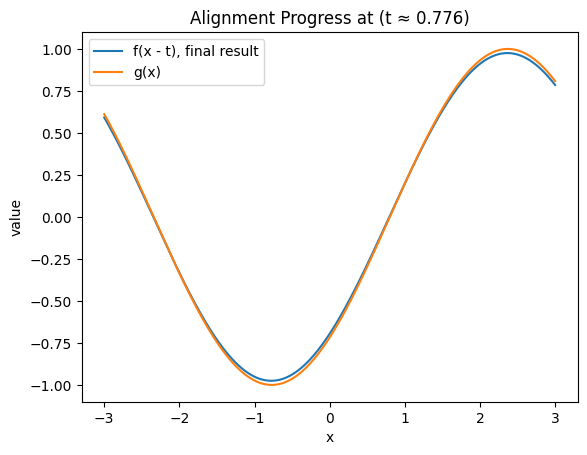

In [121]:
plt.figure()
plt.plot(x, f_shifted.detach().numpy(), label=f"f(x - t), final result")
plt.plot(x, g, label="g(x)")
plt.legend()
plt.title(f"Alignment Progress at (t ≈ {t.detach().numpy():.3f})")
plt.xlabel("x")
plt.ylabel("value")
plt.show()

**روش دوم**

استفاده از Interpolation 

In [122]:
def linear_shift_interpolate(signal, x, shift):
    x_shifted = x - shift

    idx = torch.searchsorted(x, x_shifted) - 1
    idx = torch.clamp(idx, 0, len(x)-2)

    x1 = x[idx]
    x2 = x[idx + 1]

    y1 = signal[idx]
    y2 = signal[idx + 1]

    w = (x_shifted - x1) / (x2 - x1 + 1e-8)

    return y1 + w * (y2 - y1)


In [123]:
x = torch.linspace(-3, 3, 300)

f = torch.sin(x)
true_shift = 0.8
g = torch.sin(x - true_shift)

# reshape to (N,C,H,W)
f_signal = f.view(1, 1, 1, -1)

t = torch.tensor(0.0, requires_grad=True)
optimizer = torch.optim.SGD([t], lr=0.1)
f_shifted = None
for step in range(40):
    optimizer.zero_grad()

    f_shifted = linear_shift_interpolate(f, x, t)

    loss = ((f_shifted - g)**2).mean()

    loss.backward()
    optimizer.step()

print("Estimated shift =", t.item())

Estimated shift = 0.7859838604927063


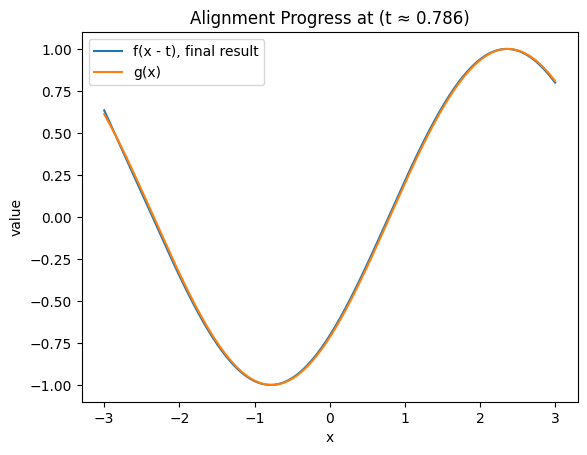

In [124]:
plt.figure()
plt.plot(x, f_shifted.detach().numpy(), label=f"f(x - t), final result")
plt.plot(x, g, label="g(x)")
plt.legend()
plt.title(f"Alignment Progress at (t ≈ {t.detach().numpy():.3f})")
plt.xlabel("x")
plt.ylabel("value")
plt.show()